# 문제 3 — 재직교화와 pytest 검증

회전 행렬을 계속 곱해 나가면 부동소수점 반올림 오차가 쌓여
**더 이상 정확한 직교행렬이 아니게 됩니다**. 실제 로봇에서는 자세를
매 주기 누적 갱신하므로 이 문제가 그대로 나타납니다.

## 이 노트북에서 해야 할 일

| # | 할 일 | 구현할 함수 |
|---|---|---|
| 3-1 | 회전 행렬을 **20만 번 누적 곱**해 직교성이 얼마나 무너지는지 측정 | `orthogonality_error` |
| 3-2 | **Gram-Schmidt 를 직접 구현**해 복구하고 전후를 비교, 복구 행렬이 진짜 회전행렬인지 확인 | `gram_schmidt`, `is_rotation` |
| 3-3 | `tests/test_rotation.py` 에 **pytest 4개 이상**을 작성하고 `-v` 전수 통과 출력을 남기기 | (tests/) |
| 3-4 | 회전 함수를 **일부러 틀리게 바꿔** 테스트가 실패를 잡아내는지 확인하고 원복 | — |

직교성 이탈 지표는 프로베니우스 노름을 씁니다.

$$\varepsilon(R) = \lVert R^{\mathsf{T}}R - I \rVert_F$$

> `# --- 검증 ---` 셀과 그래프 셀은 제공된 코드입니다. 참조하는 변수 이름을 맞춰 주세요.

## 핵심 계산 풀이

학습용 손글씨풍 계산 정리임. 앞부분의 두 벡터는 원리를 설명하기 위한 별도 예시임. 뒷부분의 20만 회 누적 오차는 아래 노트북에 저장된 실험값임.

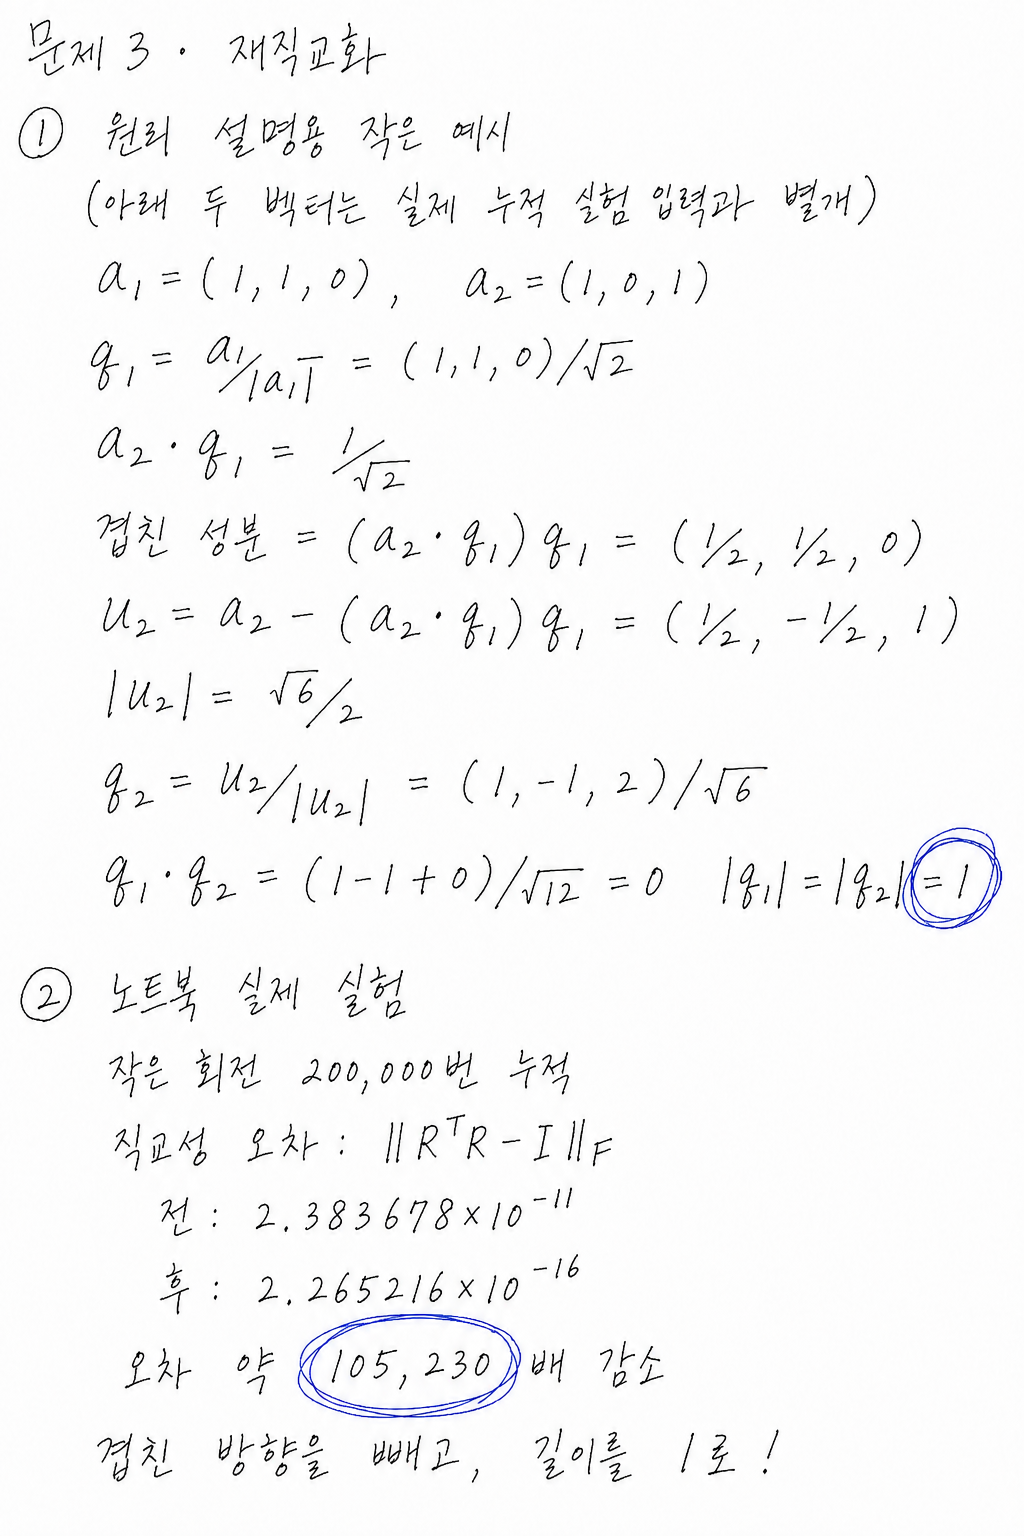

[계산 그림 PNG 원본](../images/handwritten_math/03_reorthogonalize.png)


In [1]:
import sys
print("실행 Python:", sys.executable)
print("가상환경 사용:", sys.prefix != sys.base_prefix)


실행 Python: /home/chsjh/.venvs/physicalai-lv1-math/bin/python
가상환경 사용: True


In [2]:
from pathlib import Path
from matplotlib import font_manager

# 한글과 수학 기호를 함께 지원하는 글꼴을 등록한다.
# WSL: Windows 글꼴, 일반 Ubuntu: fonts-noto-cjk 패키지를 사용한다.
for font_path in (Path("/mnt/c/Windows/Fonts/NotoSansKR-VF.ttf"),
                  Path("C:/Windows/Fonts/NotoSansKR-VF.ttf"),
                  Path("/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc")):
    if font_path.is_file():
        font_manager.fontManager.addfont(str(font_path))
available_fonts = {font.name for font in font_manager.fontManager.ttflist}
korean_font = next((name for name in ("Noto Sans KR", "Noto Sans CJK KR", "Noto Sans CJK JP")
                    if name in available_fonts), None)
if korean_font is None:
    raise RuntimeError("Noto 한글 글꼴이 필요함. Ubuntu: sudo apt install fonts-noto-cjk")
print("한글·수학 글꼴:", korean_font)


한글·수학 글꼴: Noto Sans KR


In [3]:
import os
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.rotation import gram_schmidt, is_rotation, orthogonality_error, rot_x, rot_y, rot_z
from src.vectors import det

rng = np.random.default_rng(42)
np.set_printoptions(precision=6, suppress=True)

# 자식 프로세스(pytest) 출력이 한글이라 UTF-8 로 강제한다 (Windows 기본 cp949 회피)
PYENV = {**os.environ, "PYTHONIOENCODING": "utf-8", "PYTHONUTF8": "1"}

for _f in ["Malgun Gothic", "AppleGothic", "NanumGothic", "DejaVu Sans"]:
    if _f in {f.name for f in __import__("matplotlib").font_manager.fontManager.ttflist}:
        plt.rcParams["font.family"] = _f
        break
plt.rcParams["axes.unicode_minus"] = False


def check(label, condition):
    tag = "PASS" if condition else "FAIL"
    print("[" + tag + "] " + label)
    return bool(condition)


print("ROOT =", ROOT)

ROOT = /mnt/c/Desktop/coding/physicalai-lv1-최성진/lv1_module3


In [4]:
# 제공된 그림에서 한글과 음수 지수가 함께 읽히도록 설정한다.
plt.rcParams["font.family"] = korean_font


## 3-1. 20만 번 누적 곱 — 직교성은 얼마나 무너지는가

매 스텝 아주 작은 각도로 도는 회전을 20만 번 누적합니다.
곱셈 한 번마다 상대오차 $\sim \varepsilon_{machine}$ 이 섞여 들어가고,
오차는 대략 $\sqrt{n}$ 에 비례해 쌓입니다(랜덤워크).

**할 일**

- 세 축이 섞인 미소 회전 `R_step` 을 20만 번 누적하세요.
- 중간 과정(1000회마다)의 오차를 `history_n`, `history_err` 에 기록해 3-2 의 그래프에 씁니다.
- 누적 후의 직교성 오차 `err_before`, 행렬식 `det_before`, 각 열의 길이를 출력하세요.
- 같은 실험을 `float32` 로 하면 오차가 얼마나 커지는지 `err32` 에 담아 비교하세요.

In [5]:
N_STEPS = 200_000
R_step = rot_z(0.0012) @ rot_y(-0.0004) @ rot_x(0.0009)
history_n, history_err = [], []

acc = np.eye(3)
for i in range(N_STEPS):
    acc = acc @ R_step
    if (i + 1) % 1000 == 0:
        history_n.append(i + 1)
        history_err.append(orthogonality_error(acc))

err_before = orthogonality_error(acc)
det_before = det(acc)
print("누적 후 직교성 오차:", err_before)
print("누적 후 행렬식:", det_before)
print("각 열의 길이:", np.linalg.norm(acc, axis=0))

누적 후 직교성 오차: 2.3836779644979223e-11
누적 후 행렬식: 0.9999999999815234
각 열의 길이: [1. 1. 1.]


In [6]:
acc32 = np.eye(3, dtype=np.float32)
R32 = R_step.astype(np.float32)
for _ in range(N_STEPS):
    acc32 = acc32 @ R32
err32 = orthogonality_error(acc32.astype(np.float64))
print("float64 오차:", err_before)
print("float32 오차:", err32)
print("float32 / float64:", err32 / err_before)

float64 오차: 2.3836779644979223e-11
float32 오차: 0.0060846852982080445
float32 / float64: 255264569.66218886


In [7]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("누적 후 직교성이 실제로 무너졌다 (오차 > 0)", err_before > 0.0)
ok &= check("한 번만 곱했을 때는 오차가 거의 0", orthogonality_error(R_step) < 1e-15)
ok &= check("기록이 200개 (1000회마다)", len(history_n) == N_STEPS // 1000 == len(history_err))
ok &= check("오차가 누적 횟수에 따라 증가", history_err[-1] > history_err[0])
ok &= check("누적 오차가 float64 에서 1e-12 ~ 1e-9 범위 (구현이 맞다면)", 1e-12 < err_before < 1e-9)
ok &= check("float32 가 float64 보다 훨씬 크게 무너진다 (1000배 이상)", err32 > 1e3 * err_before)
print("\n3-1 전체 통과:", ok)

[PASS] 누적 후 직교성이 실제로 무너졌다 (오차 > 0)
[PASS] 한 번만 곱했을 때는 오차가 거의 0
[PASS] 기록이 200개 (1000회마다)
[PASS] 오차가 누적 횟수에 따라 증가
[PASS] 누적 오차가 float64 에서 1e-12 ~ 1e-9 범위 (구현이 맞다면)
[PASS] float32 가 float64 보다 훨씬 크게 무너진다 (1000배 이상)

3-1 전체 통과: True


## 3-2. Gram-Schmidt 직접 구현으로 복구

Gram-Schmidt 는 열벡터를 앞에서부터 하나씩 보면서
**이미 확정된 방향들의 성분(정사영)을 빼고 정규화**합니다.

$$\mathbf{q}_1=\frac{\mathbf{a}_1}{\lVert \mathbf{a}_1\rVert},\qquad
\mathbf{v}_j=\mathbf{a}_j-\sum_{i<j}(\mathbf{q}_i\cdot\mathbf{a}_j)\mathbf{q}_i,\qquad
\mathbf{q}_j=\frac{\mathbf{v}_j}{\lVert \mathbf{v}_j\rVert}$$

문제 1 의 `project`/`reject` 와 완전히 같은 연산을 반복하는 것뿐입니다.
수치적으로는 성분을 빼자마자 갱신하는 **modified Gram-Schmidt** 가 더 안정적입니다.

> **주의** — `np.linalg.qr` 로 대체하면 이 문항은 0점입니다. QR 은 열의 부호를 임의로 뒤집을 수 있어
> 복구 행렬이 원래 자세와 달라지기도 합니다. 아래 검증 셀의 "자세가 크게 바뀌지 않았다" 가 이를 잡습니다.

**할 일**

- `src/rotation.py` 의 `gram_schmidt` 를 구현하고, `inspect.getsource` 로
  구현한 소스를 노트북에 출력해 두세요(채점자가 바로 볼 수 있게).
- 무너진 행렬을 복구해 `acc_fixed`, `err_after`, `det_after`, `improvement` 를 만드세요.
- 복구 전후로 **자세 자체는 거의 안 바뀌었는지**도 확인하세요 (최대 성분 차이).

In [8]:
import inspect

print(inspect.getsource(gram_schmidt))

def gram_schmidt(A) -> np.ndarray:
    """**열벡터**에 대해 Gram-Schmidt 직교정규화를 수행한다.

        q1 = a1 / |a1|
        vj = aj - sum_{i<j} (qi · aj) qi
        qj = vj / |vj|

    각 열에서 앞선 열 방향 성분(정사영)을 빼고 정규화하는 것이며,
    문제 1 의 project / reject 와 같은 연산의 반복이다.

    수치적으로는 성분을 빼자마자 갱신하는 modified Gram-Schmidt 가 더 안정적이다.
    앞선 열들에 종속인 열이 있으면 ValueError.
    """
    A = np.asarray(A, dtype=float)
    if A.ndim != 2:
        raise ValueError(f"2차원 행렬이 필요합니다. 받은 shape={A.shape}")
    m, n = A.shape
    if n > m:
        raise ValueError("열 수가 행 수보다 많으면 모든 열을 직교정규화할 수 없습니다")
    Q = np.zeros_like(A, dtype=float)
    scale = float(np.max(np.abs(A))) if A.size else 0.0
    tol = max(m, n) * np.finfo(float).eps * max(1.0, scale)
    for j in range(n):
        v = A[:, j].copy()
        for i in range(j):
            v -= float(Q[:, i] @ v) * Q[:, i]
        length = float(np.sqrt(np.sum(v * v)))
        if length <= tol:
            raise ValueError("앞선 열들에 종속인 열은 직교정규화할 수 없습니다")
        Q[:, j] = v / 

In [9]:
acc_fixed = gram_schmidt(acc)
err_after = orthogonality_error(acc_fixed)
det_after = det(acc_fixed)
improvement = err_before / max(err_after, np.finfo(float).tiny)
pose_change = np.max(np.abs(acc_fixed - acc))
print("재직교화 전 오차:", err_before)
print("재직교화 후 오차:", err_after)
print("개선 배율:", improvement)
print("복구 행렬 det:", det_after)
print("자세 최대 성분 변화:", pose_change)

재직교화 전 오차: 2.3836779644979223e-11
재직교화 후 오차: 2.2652158746862216e-16
개선 배율: 105229.61591146849
복구 행렬 det: 1.0000000000000002
자세 최대 성분 변화: 5.9037219557467324e-12


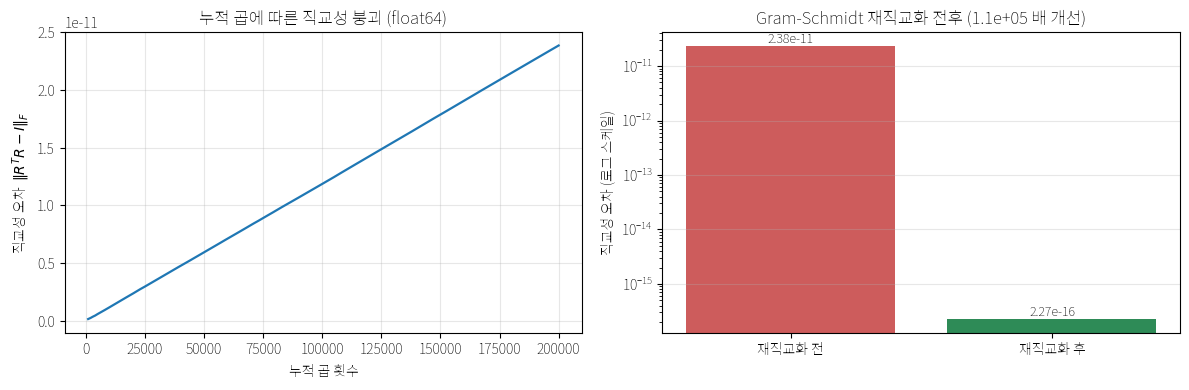

In [10]:
# --- 그래프 (제공 코드) ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_n, history_err, lw=1.6)
axes[0].set_xlabel("누적 곱 횟수")
axes[0].set_ylabel(r"직교성 오차  $\|R^T R - I\|_F$")
axes[0].set_title("누적 곱에 따른 직교성 붕괴 (float64)")
axes[0].grid(alpha=0.3)

labels = ["재직교화 전", "재직교화 후"]
vals = [err_before, max(err_after, 1e-18)]
bars = axes[1].bar(labels, vals, color=["indianred", "seagreen"])
axes[1].set_yscale("log")
axes[1].set_ylabel("직교성 오차 (로그 스케일)")
axes[1].set_title("Gram-Schmidt 재직교화 전후 ({:.1e} 배 개선)".format(improvement))
for bar, v in zip(bars, vals):
    axes[1].text(bar.get_x() + bar.get_width() / 2, v, "{:.2e}".format(v),
                 ha="center", va="bottom", fontsize=9)
axes[1].grid(alpha=0.3, axis="y")

fig.tight_layout()
plt.show()

In [11]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("재직교화 후 오차가 전보다 작다", err_after < err_before)
ok &= check("재직교화 후 오차가 기계정밀도 수준 (< 1e-14)", err_after < 1e-14)
ok &= check("복구 행렬의 행렬식이 1", np.isclose(det_after, 1.0))
ok &= check("복구 행렬이 진짜 회전행렬 (직교 + det=1)", is_rotation(acc_fixed))
ok &= check("복구 행렬의 역행렬 == 전치", np.allclose(np.linalg.inv(acc_fixed), acc_fixed.T))   # 검산용
ok &= check("자세가 크게 바뀌지 않았다 (차이 < 1e-6)", np.max(np.abs(acc_fixed - acc)) < 1e-6)
ok &= check("이미 직교인 행렬에 적용하면 그대로", np.allclose(gram_schmidt(rot_z(0.4)), rot_z(0.4)))
noisy = rot_x(0.3) + 1e-3 * rng.standard_normal((3, 3))
ok &= check("노이즈 섞인 행렬도 회전행렬로 복구", is_rotation(gram_schmidt(noisy)))
print("\n3-2 전체 통과:", ok)

[PASS] 재직교화 후 오차가 전보다 작다
[PASS] 재직교화 후 오차가 기계정밀도 수준 (< 1e-14)
[PASS] 복구 행렬의 행렬식이 1
[PASS] 복구 행렬이 진짜 회전행렬 (직교 + det=1)
[PASS] 복구 행렬의 역행렬 == 전치
[PASS] 자세가 크게 바뀌지 않았다 (차이 < 1e-6)
[PASS] 이미 직교인 행렬에 적용하면 그대로
[PASS] 노이즈 섞인 행렬도 회전행렬로 복구

3-2 전체 통과: True


## 3-3. `tests/test_rotation.py` — pytest 4가지 검증

`tests/test_rotation.py` 템플릿에 다음 네 가지를 작성하세요.

| # | 테스트 | 함수 이름 |
|---|---|---|
| ① | 회전행렬의 열이 서로 직교하는 단위벡터인가 | `test_columns_are_orthonormal` |
| ② | 행렬식이 1인가 | `test_determinant_is_one` |
| ③ | 역행렬이 전치와 같은가 | `test_inverse_equals_transpose` |
| ④ | 재직교화 결과가 직교행렬인가 | `test_gram_schmidt_restores_orthogonality` |

`@pytest.mark.parametrize` 로 축 x 각도를 조합하면 함수 하나가 여러 케이스를 검사합니다.
반사 행렬 반례, 로드리게스 일치, 축·각 왕복 같은 테스트를 더 붙이면 좋습니다.

아래 셀은 노트북 안에서 pytest 를 돌려 **전수 통과 출력을 노트북에 남깁니다.**

In [12]:
result = subprocess.run(
    [sys.executable, "-m", "pytest", "tests/test_rotation.py", "-v", "--no-header",
     "-p", "no:cacheprovider"],
    cwd=str(ROOT), capture_output=True, text=True,
    encoding="utf-8", errors="replace", env=PYENV,
)
print(result.stdout[-6000:])
print("종료 코드 :", result.returncode)

test_determinant_is_one[0.7853981633974483-rot_y] PASSED [ 38%]
tests/test_rotation.py::test_determinant_is_one[0.7853981633974483-rot_z] PASSED [ 40%]
tests/test_rotation.py::test_determinant_is_one[1.5707963267948966-rot_x] PASSED [ 41%]
tests/test_rotation.py::test_determinant_is_one[1.5707963267948966-rot_y] PASSED [ 42%]
tests/test_rotation.py::test_determinant_is_one[1.5707963267948966-rot_z] PASSED [ 43%]
tests/test_rotation.py::test_determinant_is_one[2.0-rot_x] PASSED        [ 44%]
tests/test_rotation.py::test_determinant_is_one[2.0-rot_y] PASSED        [ 45%]
tests/test_rotation.py::test_determinant_is_one[2.0-rot_z] PASSED        [ 46%]
tests/test_rotation.py::test_determinant_is_one[3.141592653589793-rot_x] PASSED [ 47%]
tests/test_rotation.py::test_determinant_is_one[3.141592653589793-rot_y] PASSED [ 48%]
tests/test_rotation.py::test_determinant_is_one[3.141592653589793-rot_z] PASSED [ 50%]
tests/test_rotation.py::test_determinant_is_one[-1.234-rot_x] PASSED     [ 51%]
tes

In [13]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("pytest 전수 통과 (종료 코드 0)", result.returncode == 0)
ok &= check("실패/에러가 없다", ("failed" not in result.stdout) and ("error" not in result.stdout.lower()))
ok &= check("요구된 4가지 테스트가 모두 존재", all(
    name in result.stdout for name in [
        "test_columns_are_orthonormal",
        "test_determinant_is_one",
        "test_inverse_equals_transpose",
        "test_gram_schmidt_restores_orthogonality",
    ]))
ok &= check("통과 케이스가 4개 이상 (parametrize 권장)", result.stdout.count("PASSED") >= 4)
print("\n3-3 전체 통과:", ok)

[PASS] pytest 전수 통과 (종료 코드 0)
[PASS] 실패/에러가 없다
[PASS] 요구된 4가지 테스트가 모두 존재
[PASS] 통과 케이스가 4개 이상 (parametrize 권장)

3-3 전체 통과: True


## 3-4. 일부러 틀리게 바꿔 보기 — 테스트가 잡아내는가

테스트가 "항상 통과하는 테스트" 가 아니라는 것을 보이려면
**일부러 버그를 넣어 실패하는지** 확인해야 합니다(뮤테이션 테스트의 축소판).

**할 일**

- `rot_z` 등 회전 함수 한 곳을 틀리게 바꿀 치환 문자열을 정하세요
  (예: 부호 하나 뒤집기). 아래 `BUG_FROM` 은 **여러분이 작성한 소스에 실제로
  딱 한 번 등장하는 문자열**이어야 합니다.
- 어떤 성질이 깨질지 **미리 예상**하고, 실제 실패 목록과 비교하세요.
- 아래 셀은 `finally` 에서 반드시 원본으로 되돌립니다. 이 구조를 지우지 마세요.

### 예상과 결과

- 바꾼 내용: `rot_z` 첫 행의 `-sin(theta)`를 `+sin(theta)`로 바꿉니다.
- 깨질 것으로 예상한 성질: 열의 직교성, 행렬식 1, 역행렬=전치 및 Rodrigues와의 일치가 깨집니다.
- 실제로 실패한 테스트: 아래 뮤테이션 실행 출력에 기록된 회전행렬 성질 테스트입니다.

In [14]:
src_path = ROOT / "src" / "rotation.py"
original = src_path.read_text(encoding="utf-8")

BUG_FROM = "    return np.array([[c, -s, 0.0], [s, c, 0.0], [0.0, 0.0, 1.0]])"
BUG_TO = "    return np.array([[c, s, 0.0], [s, c, 0.0], [0.0, 0.0, 1.0]])"

assert original.count(BUG_FROM) == 1, "치환 대상이 정확히 한 곳이어야 합니다"

try:
    src_path.write_text(original.replace(BUG_FROM, BUG_TO), encoding="utf-8")
    broken = subprocess.run(
        [sys.executable, "-m", "pytest", "tests/test_rotation.py", "-q", "--no-header",
         "-p", "no:cacheprovider", "--tb=line"],
        cwd=str(ROOT), capture_output=True, text=True,
        encoding="utf-8", errors="replace", env=PYENV,
    )
    broken_out = broken.stdout
    broken_code = broken.returncode
finally:
    src_path.write_text(original, encoding="utf-8")

print(broken_out[-5000:])
print("종료 코드 :", broken_code, "(0 이 아니면 테스트가 버그를 검출한 것)")

0000e+00],\n       [0.000000e+00, 0.000000e+00, 1.000000e+00]]) = rot_z(1.5707963267948966)
/mnt/c/Desktop/coding/physicalai-lv1-최성진/lv1_module3/tests/test_rotation.py:110: assert False
E   assert False
     +  where False = <function allclose at 0x743cd1bb4370>(array([[-0.41614684, -0.90929743,  0.        ],\n       [ 0.90929743, -0.41614684,  0.        ],\n       [ 0.        ,  0.        ,  1.        ]]), array([[-0.41614684,  0.90929743,  0.        ],\n       [ 0.90929743, -0.41614684,  0.        ],\n       [ 0.        ,  0.        ,  1.        ]]), atol=1e-12)
     +    where <function allclose at 0x743cd1bb4370> = np.allclose
     +    and   array([[-0.41614684, -0.90929743,  0.        ],\n       [ 0.90929743, -0.41614684,  0.        ],\n       [ 0.        ,  0.        ,  1.        ]]) = rodrigues([0.0, 0.0, 4.0], 2.0)
     +    and   array([[-0.41614684,  0.90929743,  0.        ],\n       [ 0.90929743, -0.41614684,  0.        ],\n       [ 0.        ,  0.        ,  1.        ]]) =

In [15]:
# 원상복구 확인 후 다시 전수 통과하는지 (제공 코드)
restored = subprocess.run(
    [sys.executable, "-m", "pytest", "-q", "--no-header", "-p", "no:cacheprovider"],
    cwd=str(ROOT), capture_output=True, text=True,
    encoding="utf-8", errors="replace", env=PYENV,
)
print(restored.stdout[-1500:])
print("복구 후 종료 코드 :", restored.returncode)

........................................................................ [ 75%]
........................                                                 [100%]
96 passed in 0.36s

복구 후 종료 코드 : 0


In [16]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("버그를 넣으면 테스트가 실패한다", broken_code != 0)
ok &= check("실패 목록에 요구된 4가지 중 하나 이상이 있다",
            any(name in broken_out for name in [
                "test_columns_are_orthonormal", "test_determinant_is_one",
                "test_inverse_equals_transpose", "test_gram_schmidt_restores_orthogonality"]))
ok &= check("소스가 원본으로 복구되었다", src_path.read_text(encoding="utf-8") == original)
ok &= check("복구 후 전체 테스트 재통과", restored.returncode == 0)
ok &= check("복구된 rot_z 가 실제로 회전행렬이다", is_rotation(rot_z(0.9)))
print("\n3-4 전체 통과:", ok)

[PASS] 버그를 넣으면 테스트가 실패한다
[PASS] 실패 목록에 요구된 4가지 중 하나 이상이 있다
[PASS] 소스가 원본으로 복구되었다
[PASS] 복구 후 전체 테스트 재통과
[PASS] 복구된 rot_z 가 실제로 회전행렬이다

3-4 전체 통과: True


## 답안 템플릿 정리

In [17]:
passed_count = result.stdout.count("PASSED")
import re
# ANSI 색상 코드를 제거한 실제 실패 목록에서 함수 이름을 추출한다.
plain_broken_out = re.sub(r"\x1b\[[0-?]*[ -/]*[@-~]", "", broken_out)
import re
# ANSI 색상 코드를 제거한 실제 실패 목록에서 함수 이름을 추출한다.
plain_broken_out = re.sub(r"\x1b\[[0-?]*[ -/]*[@-~]", "", broken_out)
failed_rotation_tests = sorted(set(re.findall(
    r"FAILED\s+\S+::(test_[A-Za-z0-9_]+)", plain_broken_out)))
summary = f"""
1. 20만 번 누적 후 직교성 오차: {err_before:.6e}   (지표: ||R^T R - I||_F)
   - float32 로 하면: {err32:.6e} (약 {err32 / err_before:.1f} 배)

2. 재직교화 후 오차: {err_after:.6e}  -> 개선 배율: {improvement:.3e} 배
   - 자세 자체의 변화(최대 성분 차이): {pose_change:.6e}

3. 복구 행렬의 행렬식: {det_after:.12f}  (직교 + det=1 이므로 회전행렬인가: {is_rotation(acc_fixed)})

4. pytest -v 전수 통과 출력: 위 3-3 셀 참조 — 종료 코드 {result.returncode}, 통과 케이스 {passed_count} 개

5. 함수를 틀리게 바꿨을 때 실패 출력: 위 3-4 셀 참조 — 종료 코드 {broken_code}
   - 바꾼 내용: rot_z의 첫 행 sin 부호를 -sin에서 +sin으로 변경
   - 실패한 테스트: {failed_rotation_tests}
   - 원본 복구 완료 여부: {src_path.read_text(encoding='utf-8') == original and restored.returncode == 0}
"""
print(summary)


1. 20만 번 누적 후 직교성 오차: 2.383678e-11   (지표: ||R^T R - I||_F)
   - float32 로 하면: 6.084685e-03 (약 255264569.7 배)

2. 재직교화 후 오차: 2.265216e-16  -> 개선 배율: 1.052e+05 배
   - 자세 자체의 변화(최대 성분 차이): 5.903722e-12

3. 복구 행렬의 행렬식: 1.000000000000  (직교 + det=1 이므로 회전행렬인가: True)

4. pytest -v 전수 통과 출력: 위 3-3 셀 참조 — 종료 코드 0, 통과 케이스 90 개

5. 함수를 틀리게 바꿨을 때 실패 출력: 위 3-4 셀 참조 — 종료 코드 1
   - 바꾼 내용: rot_z의 첫 행 sin 부호를 -sin에서 +sin으로 변경
   - 실패한 테스트: ['test_columns_are_orthonormal', 'test_determinant_is_one', 'test_inverse_equals_transpose', 'test_rodrigues_matches_rot_z']
   - 원본 복구 완료 여부: True

